# Phase 0: Reproducing Original Beyond Rate — Input-Perturbation Results

This notebook visualises the Phase 0 reproduction experiments.  
At both train and test time, a fraction **f** of input spikes are randomly relocated (preserving spike count per neuron). A separate model is trained for each f.

- **f = 0**: clean input.  
- **f = 1**: input timing fully randomised.

Two model variants are compared:
- **Learnable Tau** (SGD) — SNN with learnable membrane time constants.
- **Tau + Delay** (SGD-delay) — adds learnable axonal delays.

In [1]:
import json
import pathlib
import numpy as np
import h5py
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---------- global style ----------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

BASE = pathlib.Path(".")  # notebook lives in code/synthetic/

## ISI & CCISI — Accuracy vs Input-Layer Perturbation

ISI and CCISI both encode class information in spike timing. This plot shows how accuracy degrades as input timing is progressively randomised, comparing the SGD (learnable tau) and SGD-delay (tau + delay) variants across both tasks.

The dashed **Random Guess (50%)** line is the chance level for the binary classification tasks.

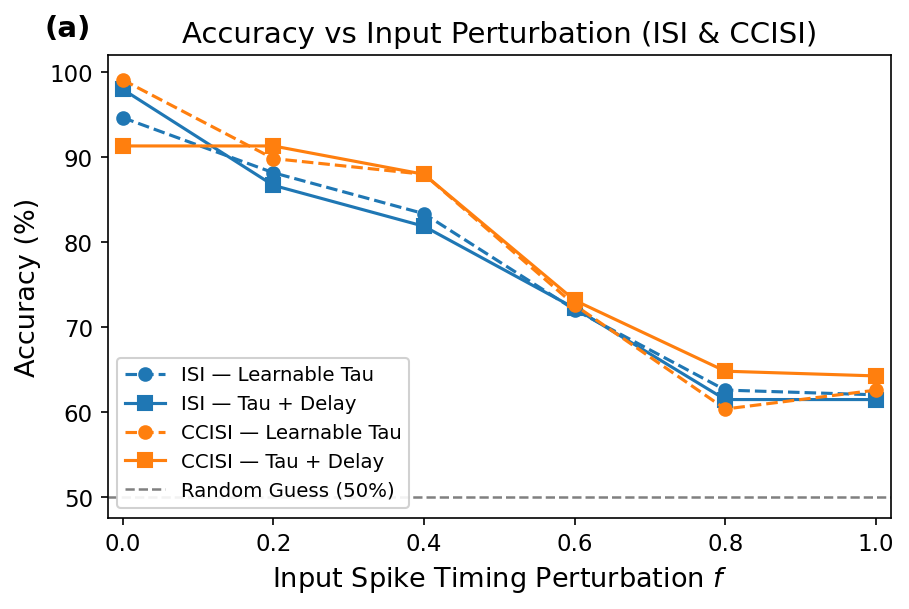

In [2]:
def load_results(path: pathlib.Path) -> tuple[list[float], np.ndarray]:
    """Load a flat {f: accuracy} JSON and return (f_values, accuracies_pct).

    The Phase 0 result files have shape ``{"0.0": 0.97, "0.2": 0.71, ...}``
    (single accuracy per f, no repeats / std).
    """
    with open(path) as fh:
        raw = json.load(fh)
    f_vals = sorted(float(k) for k in raw)
    accs = np.array([float(raw[str(f)]) for f in f_vals]) * 100
    return f_vals, accs


# --- load ISI results ---
isi_tau_f, isi_tau_acc = load_results(BASE / "isi/log/isi_tau_input_perturbation_results.json")
isi_del_f, isi_del_acc = load_results(BASE / "isi/log/isi_delay_input_perturbation_results.json")

# --- load CCISI results ---
ccisi_tau_f, ccisi_tau_acc = load_results(BASE / "ccisi/log/ccisi_tau_input_perturbation_results.json")
ccisi_del_f, ccisi_del_acc = load_results(BASE / "ccisi/log/ccisi_delay_input_perturbation_results.json")

guess_baseline = 50

# --- colours ---
BLUE = "#1f77b4"   # ISI
ORANGE = "#ff7f0e"  # CCISI

fig, ax = plt.subplots(figsize=(6.2, 4.2))

# ISI curves
ax.plot(isi_tau_f, isi_tau_acc, "o--", color=BLUE, markersize=6, label="ISI — Learnable Tau")
ax.plot(isi_del_f, isi_del_acc, "s-", color=BLUE, markersize=7, label="ISI — Tau + Delay")

# CCISI curves
ax.plot(ccisi_tau_f, ccisi_tau_acc, "o--", color=ORANGE, markersize=6, label="CCISI — Learnable Tau")
ax.plot(ccisi_del_f, ccisi_del_acc, "s-", color=ORANGE, markersize=7, label="CCISI — Tau + Delay")

# Random guess baseline
ax.axhline(guess_baseline, color="gray", linestyle="--", linewidth=1.2, label="Random Guess (50%)")

# --- axes & labels ---
ax.set_xlabel("Input Spike Timing Perturbation $f$")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy vs Input Perturbation (ISI & CCISI)")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(None, 102)
ax.legend(loc="lower left", framealpha=0.9)

ax.text(-0.08, 1.04, "(a)", transform=ax.transAxes, fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show()